# Chapter 27 — Matrix Multiplication

In Chapter 26, we represented matrices as rectangular tables and multiplied a matrix by a vector.

This chapter introduces **matrix multiplication**, which combines two matrices to produce another matrix.

The central idea is simple: each result entry is the dot product of one row from the first matrix and one column from the second matrix.

## Learning goals

By the end of this chapter, you should be able to:

1. Explain matrix multiplication as many row-column dot products.
2. Identify the shapes of the two input matrices.
3. Check whether their inner dimensions match.
4. Determine the output shape from the outer dimensions.
5. Implement matrix multiplication with nested Python loops.
6. Trace every dot product that creates an output entry.
7. Explain why matrix multiplication is not element-by-element multiplication.
8. Explain why multiplication order matters.
9. Use NumPy's `@` operator and verify the result.
10. Connect matrix multiplication to batches and parameter transformations.

## The shape rule

Suppose matrix `A` has shape `2 × 3` and matrix `B` has shape `3 × 4`.

The product `A × B` is defined because the 3 columns of `A` match the 3 rows of `B`.

The result has shape `2 × 4`:

```text
(2 × 3) × (3 × 4) = 2 × 4
     └─────┘
   inner dimensions match
```

The matching inner dimensions disappear from the result, while the outer dimensions become its shape.

## Terms used in this chapter

The **inner dimensions** are the first matrix's column count and the second matrix's row count.

The **outer dimensions** are the first matrix's row count and the second matrix's column count.

A **result entry** is one number in the output matrix.

A **shared index** moves across a selected row of the first matrix and down a selected column of the second matrix.

Matrix multiplication is defined only when the two inner dimensions are equal.

## Use one consistent example

The first matrix has shape `2 × 3`.

The second matrix has shape `3 × 4`.

Their product must therefore have shape `2 × 4`.

In [1]:
first_matrix = [
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
]

second_matrix = [
    [10.0, 20.0, 30.0, 40.0],
    [50.0, 60.0, 70.0, 80.0],
    [90.0, 100.0, 110.0, 120.0],
]

print("First matrix:")
for row in first_matrix:
    print(row)

print()
print("Second matrix:")
for row in second_matrix:
    print(row)

First matrix:
[1.0, 2.0, 3.0]
[4.0, 5.0, 6.0]

Second matrix:
[10.0, 20.0, 30.0, 40.0]
[50.0, 60.0, 70.0, 80.0]
[90.0, 100.0, 110.0, 120.0]


## Validate matrices and inspect shapes

We will reuse the rectangular numeric-matrix checks from Chapter 26.

The validator rejects empty, ragged, nonnumeric, and boolean-valued matrices before multiplication begins.

In [2]:
from collections.abc import Sequence


def assert_matrix_of_numbers(matrix: Sequence[Sequence[object]]) -> None:
    if len(matrix) == 0:
        raise ValueError("A matrix must contain at least one row.")

    number_of_columns = len(matrix[0])

    if number_of_columns == 0:
        raise ValueError("A matrix must contain at least one column.")

    for row_index, row in enumerate(matrix):
        if len(row) != number_of_columns:
            raise ValueError(
                "Every row must have the same number of columns. "
                f"Row 0 has {number_of_columns}, but row {row_index} has {len(row)}."
            )

        for column_index, entry in enumerate(row):
            is_number = isinstance(entry, (int, float))

            if not is_number or isinstance(entry, bool):
                raise TypeError(
                    f"Entry at row {row_index}, column {column_index} "
                    f"must be an int or float. Received {entry!r}."
                )


def get_matrix_shape(matrix: Sequence[Sequence[object]]) -> tuple[int, int]:
    assert_matrix_of_numbers(matrix)

    return len(matrix), len(matrix[0])

In [3]:
first_rows, first_columns = get_matrix_shape(first_matrix)
second_rows, second_columns = get_matrix_shape(second_matrix)

print(f"First matrix shape:  {first_rows} × {first_columns}")
print(f"Second matrix shape: {second_rows} × {second_columns}")
print("Inner dimensions:", first_columns, "and", second_rows)
print("Inner dimensions match:", first_columns == second_rows)

First matrix shape:  2 × 3
Second matrix shape: 3 × 4
Inner dimensions: 3 and 3
Inner dimensions match: True


### Summarize compatibility and output shape

The next helper reports compatibility without attempting the multiplication.

In [4]:
def print_matrix_multiplication_shape_summary(
    first_matrix: list[list[float]],
    second_matrix: list[list[float]],
) -> None:
    first_rows, first_columns = get_matrix_shape(first_matrix)
    second_rows, second_columns = get_matrix_shape(second_matrix)

    print("Matrix multiplication shape summary")
    print("-" * 48)
    print(f"First matrix:  {first_rows} × {first_columns}")
    print(f"Second matrix: {second_rows} × {second_columns}")
    print(f"Inner dimensions: {first_columns} and {second_rows}")

    if first_columns != second_rows:
        print("Compatible: no")
        print("Reason: the inner dimensions differ.")
        return

    print("Compatible: yes")
    print(f"Result shape: {first_rows} × {second_columns}")

In [5]:
print_matrix_multiplication_shape_summary(first_matrix, second_matrix)

Matrix multiplication shape summary
------------------------------------------------
First matrix:  2 × 3
Second matrix: 3 × 4
Inner dimensions: 3 and 3
Compatible: yes
Result shape: 2 × 4


The first matrix contributes the number of result rows.

The second matrix contributes the number of result columns.

## Select the rows and columns that meet

A result entry at row `i`, column `j` comes from row `i` of the first matrix and column `j` of the second matrix.

Selecting a row uses one list index, while selecting a column gathers one entry from every row.

In [6]:
def get_matrix_column(
    matrix: list[list[float]],
    column_index: int,
) -> list[float]:
    _, number_of_columns = get_matrix_shape(matrix)

    if column_index < 0 or column_index >= number_of_columns:
        raise ValueError(f"column_index must be between 0 and {number_of_columns - 1}.")

    column = []

    for row in matrix:
        column.append(row[column_index])

    return column

In [7]:
print("Rows of the first matrix:")
for row_index, row in enumerate(first_matrix):
    print(f"row {row_index}: {row}")

print()
print("Columns of the second matrix:")
for column_index in range(second_columns):
    column = get_matrix_column(second_matrix, column_index)
    print(f"column {column_index}: {column}")

Rows of the first matrix:
row 0: [1.0, 2.0, 3.0]
row 1: [4.0, 5.0, 6.0]

Columns of the second matrix:
column 0: [10.0, 50.0, 90.0]
column 1: [20.0, 60.0, 100.0]
column 2: [30.0, 70.0, 110.0]
column 3: [40.0, 80.0, 120.0]


Every first-matrix row has length 3, and every second-matrix column has length 3.

That shared length is the matching inner dimension.

## Reuse the dot product

Each result entry is one dot product, so we restore the vector checks and dot-product helper from Chapter 25.

In [8]:
def assert_vector_of_numbers(vector: Sequence[object]) -> None:
    if len(vector) == 0:
        raise ValueError("A vector must contain at least one number.")

    for position, coordinate in enumerate(vector):
        is_number = isinstance(coordinate, (int, float))

        if not is_number or isinstance(coordinate, bool):
            raise TypeError(
                f"Coordinate at position {position} must be an int or float. "
                f"Received {coordinate!r}."
            )


def assert_same_dimension(
    first_vector: list[float],
    second_vector: list[float],
) -> None:
    assert_vector_of_numbers(first_vector)
    assert_vector_of_numbers(second_vector)

    if len(first_vector) != len(second_vector):
        raise ValueError(
            "Vectors must have the same dimension. "
            f"Received dimensions {len(first_vector)} and {len(second_vector)}."
        )


def dot_product(
    first_vector: list[float],
    second_vector: list[float],
) -> float:
    assert_same_dimension(first_vector, second_vector)

    total = 0.0

    for position in range(len(first_vector)):
        total = total + first_vector[position] * second_vector[position]

    return total

### Compute the first result entry manually

Entry `result[0][0]` uses row 0 of the first matrix and column 0 of the second matrix.

In [9]:
first_row = first_matrix[0]
first_column = get_matrix_column(second_matrix, 0)
products = []

for position in range(len(first_row)):
    products.append(first_row[position] * first_column[position])

first_result_entry = sum(products)

print("First-matrix row 0:", first_row)
print("Second-matrix column 0:", first_column)
print("Coordinate products:", products)
print("Sum:", first_result_entry)

assert first_result_entry == 380.0

First-matrix row 0: [1.0, 2.0, 3.0]
Second-matrix column 0: [10.0, 50.0, 90.0]
Coordinate products: [10.0, 100.0, 270.0]
Sum: 380.0


The calculation is `1×10 + 2×50 + 3×90 = 380`.

Only one row and one column are needed for one result entry.

## Implement matrix multiplication with nested loops

The outer loop visits every first-matrix row.

The next loop visits every second-matrix column.

Their dot product becomes one result entry.

In [10]:
def multiply_matrices(
    first_matrix: list[list[float]],
    second_matrix: list[list[float]],
) -> list[list[float]]:
    first_rows, first_columns = get_matrix_shape(first_matrix)
    second_rows, second_columns = get_matrix_shape(second_matrix)

    if first_columns != second_rows:
        raise ValueError(
            "Matrix multiplication requires matching inner dimensions. "
            f"The first matrix has {first_columns} columns, "
            f"but the second matrix has {second_rows} rows."
        )

    result_matrix = []

    for first_row_index in range(first_rows):
        result_row = []
        first_matrix_row = first_matrix[first_row_index]

        for second_column_index in range(second_columns):
            second_matrix_column = get_matrix_column(
                second_matrix,
                second_column_index,
            )
            result_entry = dot_product(first_matrix_row, second_matrix_column)
            result_row.append(result_entry)

        result_matrix.append(result_row)

    return result_matrix

In [11]:
result_matrix = multiply_matrices(first_matrix, second_matrix)
result_shape = get_matrix_shape(result_matrix)

print("Result matrix:")
for row in result_matrix:
    print(row)

print("Result shape:", result_shape)

expected_result = [
    [380.0, 440.0, 500.0, 560.0],
    [830.0, 980.0, 1130.0, 1280.0],
]

assert result_matrix == expected_result
assert result_shape == (2, 4)

Result matrix:
[380.0, 440.0, 500.0, 560.0]
[830.0, 980.0, 1130.0, 1280.0]
Result shape: (2, 4)


The output contains two rows because the first matrix has two rows.

It contains four columns because the second matrix has four columns.

## Trace every result entry

The next function prints the row, column, coordinate products, sum, and destination for each dot product.

In [12]:
def print_matrix_multiplication_steps(
    first_matrix: list[list[float]],
    second_matrix: list[list[float]],
) -> list[list[float]]:
    first_rows, first_columns = get_matrix_shape(first_matrix)
    second_rows, second_columns = get_matrix_shape(second_matrix)

    if first_columns != second_rows:
        raise ValueError(
            "Matrix multiplication requires matching inner dimensions. "
            f"Received {first_columns} and {second_rows}."
        )

    result_matrix = []

    print("Matrix multiplication steps")
    print("-" * 60)
    print(
        f"Shapes: ({first_rows} × {first_columns}) × ({second_rows} × {second_columns})"
    )
    print(f"Result shape: {first_rows} × {second_columns}")
    print()

    for row_index in range(first_rows):
        result_row = []
        selected_row = first_matrix[row_index]

        for column_index in range(second_columns):
            selected_column = get_matrix_column(second_matrix, column_index)
            products = []

            for shared_index in range(first_columns):
                product = selected_row[shared_index] * selected_column[shared_index]
                products.append(product)

            result_entry = sum(products)
            result_row.append(result_entry)

            print(f"result[{row_index}][{column_index}]")
            print("  row:     ", selected_row)
            print("  column:  ", selected_column)
            print("  products:", products)
            print("  sum:     ", result_entry)
            print()

        result_matrix.append(result_row)

    print("Final result:")
    for row in result_matrix:
        print(row)

    return result_matrix

In [13]:
traced_result = print_matrix_multiplication_steps(
    first_matrix,
    second_matrix,
)

assert traced_result == expected_result

Matrix multiplication steps
------------------------------------------------------------
Shapes: (2 × 3) × (3 × 4)
Result shape: 2 × 4

result[0][0]
  row:      [1.0, 2.0, 3.0]
  column:   [10.0, 50.0, 90.0]
  products: [10.0, 100.0, 270.0]
  sum:      380.0

result[0][1]
  row:      [1.0, 2.0, 3.0]
  column:   [20.0, 60.0, 100.0]
  products: [20.0, 120.0, 300.0]
  sum:      440.0

result[0][2]
  row:      [1.0, 2.0, 3.0]
  column:   [30.0, 70.0, 110.0]
  products: [30.0, 140.0, 330.0]
  sum:      500.0

result[0][3]
  row:      [1.0, 2.0, 3.0]
  column:   [40.0, 80.0, 120.0]
  products: [40.0, 160.0, 360.0]
  sum:      560.0

result[1][0]
  row:      [4.0, 5.0, 6.0]
  column:   [10.0, 50.0, 90.0]
  products: [40.0, 250.0, 540.0]
  sum:      830.0

result[1][1]
  row:      [4.0, 5.0, 6.0]
  column:   [20.0, 60.0, 100.0]
  products: [80.0, 300.0, 600.0]
  sum:      980.0

result[1][2]
  row:      [4.0, 5.0, 6.0]
  column:   [30.0, 70.0, 110.0]
  products: [120.0, 350.0, 660.0]
  sum:   

Every one of the `2 × 4 = 8` output entries came from a separate length-3 dot product.

## The shared-index implementation

We can also create the zero-filled result first and compute entries directly with three nested loops.

The innermost `shared_index` moves across the first row and down the second column at the same time.

In [14]:
def create_zero_matrix(
    number_of_rows: int,
    number_of_columns: int,
) -> list[list[float]]:
    if number_of_rows < 1 or number_of_columns < 1:
        raise ValueError("Both matrix dimensions must be at least 1.")

    return [[0.0 for _ in range(number_of_columns)] for _ in range(number_of_rows)]


def multiply_matrices_by_filling_result(
    first_matrix: list[list[float]],
    second_matrix: list[list[float]],
) -> list[list[float]]:
    first_rows, first_columns = get_matrix_shape(first_matrix)
    second_rows, second_columns = get_matrix_shape(second_matrix)

    if first_columns != second_rows:
        raise ValueError("The inner dimensions must match.")

    result_matrix = create_zero_matrix(first_rows, second_columns)

    for result_row_index in range(first_rows):
        for result_column_index in range(second_columns):
            total = 0.0

            for shared_index in range(first_columns):
                total = total + (
                    first_matrix[result_row_index][shared_index]
                    * second_matrix[shared_index][result_column_index]
                )

            result_matrix[result_row_index][result_column_index] = total

    return result_matrix

In [15]:
filled_result = multiply_matrices_by_filling_result(
    first_matrix,
    second_matrix,
)

print("Result produced by filling output entries:")
for row in filled_result:
    print(row)

print("Matches the row-column implementation:", filled_result == result_matrix)

assert filled_result == expected_result

Result produced by filling output entries:
[380.0, 440.0, 500.0, 560.0]
[830.0, 980.0, 1130.0, 1280.0]
Matches the row-column implementation: True


Both implementations perform the same arithmetic.

The first emphasizes row-column dot products, while the second exposes the shared inner-dimension index directly.

## Shape mismatches fail before arithmetic

A `2 × 3` matrix cannot multiply a `2 × 4` matrix because the inner dimensions are 3 and 2.

In [16]:
incompatible_second_matrix = [
    [10.0, 20.0, 30.0, 40.0],
    [50.0, 60.0, 70.0, 80.0],
]

print_matrix_multiplication_shape_summary(
    first_matrix,
    incompatible_second_matrix,
)

try:
    multiply_matrices(first_matrix, incompatible_second_matrix)
except ValueError as error:
    print()
    print("Caught expected error:")
    print(error)

Matrix multiplication shape summary
------------------------------------------------
First matrix:  2 × 3
Second matrix: 2 × 4
Inner dimensions: 3 and 2
Compatible: no
Reason: the inner dimensions differ.

Caught expected error:
Matrix multiplication requires matching inner dimensions. The first matrix has 3 columns, but the second matrix has 2 rows.


The first matrix's length-3 rows cannot form dot products with the second matrix's length-2 columns.

## Matrix multiplication is not element by element

The two compatible input matrices do not even have the same shape, so pairing entries at identical positions would not make sense.

Matrix multiplication instead combines every relevant row with every relevant column and creates a new shape.

## Multiplication order matters

`A × B` and `B × A` are different operations.

For our rectangular matrices, `A × B` is defined but `B × A` is not, because the reversed inner dimensions would be 4 and 2.

In [17]:
try:
    multiply_matrices(second_matrix, first_matrix)
except ValueError as error:
    print("Caught expected reverse-order error:")
    print(error)

Caught expected reverse-order error:
Matrix multiplication requires matching inner dimensions. The first matrix has 4 columns, but the second matrix has 2 rows.


Even when both orders are defined for square matrices, the products can differ.

In [18]:
matrix_a = [
    [1.0, 2.0],
    [3.0, 4.0],
]
matrix_b = [
    [0.0, 5.0],
    [6.0, 7.0],
]

a_times_b = multiply_matrices(matrix_a, matrix_b)
b_times_a = multiply_matrices(matrix_b, matrix_a)

print("A × B:", a_times_b)
print("B × A:", b_times_a)
print("Products are equal:", a_times_b == b_times_a)

assert a_times_b != b_times_a

A × B: [[12.0, 19.0], [24.0, 43.0]]
B × A: [[15.0, 20.0], [27.0, 40.0]]
Products are equal: False


Matrix multiplication is generally **not commutative**: changing the order can change the result or make the operation undefined.

## Use NumPy's `@` operator

Pure Python makes the mechanism visible, but numerical code normally uses an array library.

NumPy arrays support matrix multiplication with `@` and enforce the same shape rule.

In [19]:
import numpy as np

first_array = np.array(first_matrix)
second_array = np.array(second_matrix)
numpy_result = first_array @ second_array

print("First NumPy shape:", first_array.shape)
print("Second NumPy shape:", second_array.shape)
print("Result NumPy shape:", numpy_result.shape)
print("NumPy result:")
print(numpy_result)

First NumPy shape:

 (2, 3)
Second NumPy shape: (3, 4)
Result NumPy shape: (2, 4)
NumPy result:
[[ 380.  440.  500.  560.]
 [ 830.  980. 1130. 1280.]]


NumPy reports the same `(2, 4)` output shape and the same eight values.

Convert the array back to nested lists for a direct comparison with our pure-Python result.

In [20]:
numpy_result_as_list = numpy_result.tolist()

print("Pure Python result:", result_matrix)
print("NumPy result as lists:", numpy_result_as_list)
print("Results match:", result_matrix == numpy_result_as_list)

assert result_matrix == numpy_result_as_list

Pure Python result: [[380.0, 440.0, 500.0, 560.0], [830.0, 980.0, 1130.0, 1280.0]]
NumPy result as lists: [[380.0, 440.0, 500.0, 560.0], [830.0, 980.0, 1130.0, 1280.0]]
Results match: True


NumPy changes the representation and implementation speed, not the underlying row-column mathematics.

In [21]:
bad_first_array = np.array(first_matrix)
bad_second_array = np.array(incompatible_second_matrix)

print("First shape:", bad_first_array.shape)
print("Incompatible second shape:", bad_second_array.shape)

try:
    bad_first_array @ bad_second_array
except ValueError as error:
    print("Caught expected NumPy shape error:")
    print(error)

First shape: (2, 3)
Incompatible second shape: (2, 4)
Caught expected NumPy shape error:
matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)


The library error is easier to interpret when we already know to compare the inner dimensions.

## Visualize one result matrix

A heatmap can help inspect the output's value pattern, but it does not replace the dot-product explanation.

The axis labels state which outer dimension produced each direction.

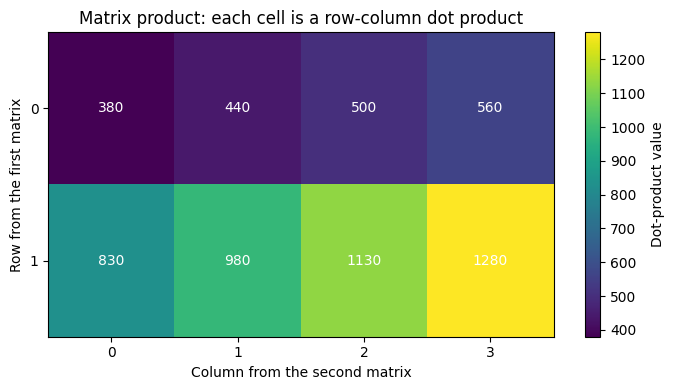

In [22]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(figsize=(7, 4))
image = axes.imshow(result_matrix, aspect="auto", cmap="viridis")
axes.set_title("Matrix product: each cell is a row-column dot product")
axes.set_xlabel("Column from the second matrix")
axes.set_ylabel("Row from the first matrix")
axes.set_xticks(range(second_columns))
axes.set_yticks(range(first_rows))

for row_index, row in enumerate(result_matrix):
    for column_index, value in enumerate(row):
        axes.text(
            column_index,
            row_index,
            f"{value:.0f}",
            ha="center",
            va="center",
            color="white",
        )

figure.colorbar(image, ax=axes, label="Dot-product value")
plt.tight_layout()
plt.show()

The heatmap has two rows from the first matrix and four columns from the second matrix.

Each printed value is one of the dot products traced earlier.

## A batch-times-parameter example

In many libraries, each data example is stored as a row vector in a batch matrix.

A `batch size × input dimension` matrix can multiply an `input dimension × output dimension` parameter matrix.

This row-vector convention differs in orientation from Chapter 26's single-column-vector view, but both use the same inner-dimension rule.

In [23]:
batch_matrix = [
    [1.0, 0.0, 2.0],
    [0.5, -1.0, 1.5],
]
parameter_matrix = [
    [0.2, 0.5, -0.1, 1.0],
    [1.5, -0.3, 0.8, 0.0],
    [-0.7, 0.4, 0.6, -0.2],
]

batch_output_matrix = multiply_matrices(batch_matrix, parameter_matrix)

print("Batch shape:", get_matrix_shape(batch_matrix))
print("Parameter shape:", get_matrix_shape(parameter_matrix))
print("Output shape:", get_matrix_shape(batch_output_matrix))
print("Output rows:")
for row in batch_output_matrix:
    print(row)

Batch shape: (2, 3)
Parameter shape: (3, 4)
Output shape: (2, 4)
Output rows:
[-1.2, 1.3, 1.0999999999999999, 0.6]
[-2.4499999999999997, 1.1500000000000001, 0.04999999999999982, 0.19999999999999996]


The shape calculation is `(2 × 3) × (3 × 4) = 2 × 4`.

Two example rows remain two result rows, while three input coordinates become four output coordinates.

A complete neural-network linear layer will later add a bias after this multiplication.

## Where matrix multiplication appears

- Linear layers transform vectors or batches with parameter matrices.
- Batch calculations process many row-vector examples together.
- Embedding-derived representations are transformed by learned matrices.
- Attention compares many vectors using matrix products, including products involving transposed matrices introduced later.

In every case, naming the axes is as important as checking their sizes.

## A clean matrix-multiplication pipeline

This final cell checks compatibility, computes the pure-Python product, verifies NumPy, and reports every shape.

In [24]:
first_matrix = [
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
]
second_matrix = [
    [10.0, 20.0, 30.0, 40.0],
    [50.0, 60.0, 70.0, 80.0],
    [90.0, 100.0, 110.0, 120.0],
]

first_rows, first_columns = get_matrix_shape(first_matrix)
second_rows, second_columns = get_matrix_shape(second_matrix)

if first_columns != second_rows:
    raise ValueError("The inner dimensions do not match.")

python_result = multiply_matrices(first_matrix, second_matrix)
pipeline_numpy_result = (np.array(first_matrix) @ np.array(second_matrix)).tolist()

print("Matrix multiplication summary")
print("-" * 48)
print(f"First shape:  {first_rows} × {first_columns}")
print(f"Second shape: {second_rows} × {second_columns}")
print(f"Result shape: {get_matrix_shape(python_result)}")
print("Pure Python result:", python_result)
print("Matches NumPy:", python_result == pipeline_numpy_result)

assert python_result == expected_result
assert python_result == pipeline_numpy_result

Matrix multiplication summary
------------------------------------------------
First shape:  2 × 3
Second shape: 3 × 4
Result shape: (2, 4)
Pure Python result: [[380.0, 440.0, 500.0, 560.0], [830.0, 980.0, 1130.0, 1280.0]]
Matches NumPy: True


## What not to do

- Do not multiply matrices unless the inner dimensions match.
- Do not confuse matrix multiplication with element-by-element multiplication.
- Do not assume `A × B` equals `B × A`.
- Do not infer output shape from the inner dimensions.
- Do not use NumPy's `@` operator without understanding what each axis means.
- Do not switch between row-vector and column-vector conventions without stating the orientation.

## Gotchas

Matrix multiplication is many row-column dot products.

For `(a × b) × (b × c)`, the matching inner dimension is `b` and the result shape is `a × c`.

Result rows come from the first matrix, and result columns come from the second matrix.

Order matters, and reversing an operation may change the answer or make it undefined.

NumPy's `@` operator follows exactly the same compatibility rule.

## Takeaways

Matrix multiplication combines two matrices through row-column dot products.

The product `(2 × 3) × (3 × 4)` is defined and produces a `2 × 4` matrix.

Each output entry selects one row from the first matrix, one column from the second matrix, multiplies matching coordinates, and sums those products.

Pure Python loops expose the mechanism, while NumPy's `@` operator performs the same operation compactly.

Reliable matrix code always tracks both dimension sizes and axis meanings.

## What comes next

The next chapter introduces tensors.

Vectors and matrices are one- and two-dimensional tensors, while language models use higher-dimensional tensors for batches, sequences, embeddings, attention scores, and model activations.